In [18]:
# cell 1 - declare root folder
import os
import sys
from pathlib import Path

# Set working directory to project root
project_root = Path(r"d:\python_projects\M4_S2_project")
os.chdir(project_root)

# Add project root to sys.path so 'src' is importable
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("cwd:", Path.cwd())
print("src on path:", (project_root / "src").exists())

cwd: d:\python_projects\M4_S2_project
src on path: True


In [19]:
# Cell 2 - Setup
from pathlib import Path

import pandas as pd
import yaml

import src.data_inspector as data_inspector
import src.data_loader as data_loader
import src.data_normalizer as data_normalizer
import src.ner as ner
import src.preprocessing as preprocessing
import src.similarity as similarity
import src.summarizer as summarizer
import src.topic_predictor as topic_predictor
from src.utils import RANDOM_SEED, release_model, setup_logging

# Config is loaded from Path.cwd() / "config" / "config.yaml".
config_path = Path.cwd() / "config" / "config.yaml"
if not config_path.exists():
    raise FileNotFoundError(
        f"config.yaml not found at {config_path}. "
        "Run Jupyter from the project root directory: "
        "cd /path/to/wikinews-nlp && jupyter notebook"
    )
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

setup_logging(log_file=config["logging"]["log_file"])
random_seed = config.get("random_seed", RANDOM_SEED)
import os
os.environ["PIPELINE_DEVICE"] = config.get("device", "auto")


In [20]:
# Cell 3 - Validate config
summarizer.validate_summarization_config(config)
ner.validate_ner_config(config)
# Both fail fast if config values are internally inconsistent.
# Catches errors before any model is loaded.

In [21]:
# Cell 4 - Download data
raw_path = data_loader.download_dataset(
    config["data"]["source_url"],
    config["data"]["raw_path"],
)

2026-05-21 14:05:32 | INFO     | src.data_loader | Skipping download: D:\python_projects\M4_S2_project\data\raw already contains data files > 102400 bytes total.


In [22]:
# Cell 5 - Raw profile (human review gate)
fmt = data_inspector.detect_format(str(raw_path))
profile = data_inspector.raw_profile(str(raw_path), fmt)
data_inspector.print_raw_profile(profile)
# HUMAN: review output. Confirm format and record count look correct before continuing.

2026-05-21 14:05:33 | INFO     | src.data_inspector | Detected format: jsonl
2026-05-21 14:05:33 | INFO     | src.data_inspector | File count: 1
2026-05-21 14:05:33 | INFO     | src.data_inspector | Total size (bytes): 45273315
2026-05-21 14:05:33 | INFO     | src.data_inspector | Total parseable records: 15200
2026-05-21 14:05:33 | INFO     | src.data_inspector | Detected fields (8): ['title', 'pageid', 'categories', 'lang', 'url', 'text', 'date', 'type']
2026-05-21 14:05:33 | INFO     | src.data_inspector | Sample record keys: ['title', 'pageid', 'categories', 'lang', 'url', 'text', 'date', 'type']
2026-05-21 14:05:33 | INFO     | src.data_inspector | Sample record (text fields truncated to 100 chars): {'title': "'Bloody Sunday Inquiry' publishes report into British Army killing of activists in Northern Ireland", 'pageid': 191513, 'categories': ['Northern Ireland', 'Martin McGuinness', 'Politics and conflicts', 'Religion', 'Europe', 'Crime and law', 'Roman Catholic Church', 'Christia

In [23]:
# Cell 6 - Category profile (config selection gate)
category_df = data_inspector.category_profile(str(raw_path), fmt)
data_inspector.print_category_profile(category_df)
display(category_df.head(50))
# HUMAN: review available category labels and counts.
# If topics.selected or countries.selected in config.yaml need changes:
#   1. Edit config/config.yaml.
#   2. Rerun Cell 2 to reload config, or run:
#        config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
#        random_seed = config.get("random_seed", RANDOM_SEED)
#   3. Rerun Cell 3 validation, then continue from Cell 7.
# No interactive input is requested in the notebook; config remains the source of truth.

2026-05-21 14:05:35 | INFO     | src.data_inspector | Total parseable records: 15200
2026-05-21 14:05:35 | INFO     | src.data_inspector | Records with no usable categories: 0
2026-05-21 14:05:35 | INFO     | src.data_inspector | Categories loaded.
2026-05-21 14:05:35 | INFO     | src.data_inspector | Review these category labels, update config.yaml topics.selected and countries.selected if needed, then rerun Cell 1 or reload config before continuing.


,category,count,percent
0,Politics and conflicts,6387,42.019737
1,Europe,4687,30.835526
2,United States,4394,28.907895
3,North America,3939,25.914474
4,Asia,3390,22.302632
5,Disasters and accidents,2780,18.289474
6,Crime and law,2763,18.177632
7,Science and technology,1861,12.243421
8,Middle East,1513,9.953947
9,Culture and entertainment,1449,9.532895


In [24]:
# Cell 7 - Normalise (NER pass: en + de)
# Note: Grouping by language only, not by country.
# See docs/decisions/0005-language-only-grouping.md for rationale.
ner_articles, dropped_ner = data_normalizer.normalise_articles(
    str(raw_path),
    fmt,
    languages=config["languages"]["ner"],
    topics=config["topics"]["selected"],
    countries=None,  # Language-only grouping; country retained as metadata
    max_per_topic=config["topics"]["articles_per_topic_ner"],
    min_article_length=config["data"]["min_article_length"],
    random_seed=random_seed,
)
data_normalizer.print_normalisation_summary(ner_articles, dropped_ner)

2026-05-21 14:05:37 | INFO     | src.data_normalizer | Total valid articles: 600
2026-05-21 14:05:37 | INFO     | src.data_normalizer | Valid by country: {'russia': 31, 'denmark': 2, 'iceland': 3, 'turkey': 11, 'armenia': 1, 'united kingdom': 30, 'italy': 14, 'united states': 80, 'afghanistan': 16, 'spain': 12, 'egypt': 4, '': 22, 'poland': 4, 'finland': 2, 'slovenia': 1, 'france': 23, 'belgium': 7, 'netherlands': 5, 'australia': 10, 'croatia': 2, 'china': 41, 'thailand': 17, 'romania': 3, 'greece': 3, 'norway': 3, 'germany': 15, 'ukraine': 4, 'libya': 3, 'guernsey': 1, 'kazakhstan': 1, 'sweden': 2, 'israel': 3, 'turkmenistan': 2, 'indonesia': 14, 'pakistan': 21, 'hong kong': 2, 'india': 14, 'taiwan': 16, 'kyrgyzstan': 5, 'philippines': 5, 'new zealand': 6, 'north korea': 6, 'bangladesh': 1, 'japan': 17, 'south korea': 2, 'singapore': 1, 'yemen': 5, 'brazil': 9, 'mexico': 6, 'chile': 9, 'bahamas': 1, 'vanuatu': 3, 'canada': 8, 'iran': 7, 'myanmar': 5, 'grenada': 1, 'south africa': 2, '

In [25]:
# Cell 8 - Normalise (summarisation pass: en only)
summ_articles, dropped_summ = data_normalizer.normalise_articles(
    str(raw_path),
    fmt,
    languages=config["languages"]["summarization"],
    topics=config["topics"]["selected"],
    countries=None,  # Language-only grouping; country retained as metadata
    max_per_topic=config["topics"]["articles_per_topic_max"],
    min_article_length=config["data"]["min_article_length"],
    random_seed=random_seed,
)
data_normalizer.print_normalisation_summary(summ_articles, dropped_summ)
# Note: ner_articles and summ_articles are separate processing pools.
# With the same random_seed, English selections are identical when both passes
# draw from the same source pool. Use random_seed + 1 for the second pass only
# if the analysis deliberately needs different English samples.

2026-05-21 14:05:38 | INFO     | src.data_normalizer | Total valid articles: 60
2026-05-21 14:05:38 | INFO     | src.data_normalizer | Valid by country: {'russia': 5, 'denmark': 1, 'iceland': 1, 'turkey': 3, 'armenia': 1, 'united kingdom': 4, 'italy': 2, 'united states': 5, 'afghanistan': 3, 'spain': 1, 'egypt': 3, '': 1, 'china': 4, 'bangladesh': 1, 'india': 1, 'japan': 2, 'nepal': 1, 'mongolia': 1, 'iran': 2, 'taiwan': 3, 'pakistan': 2, 'thailand': 2, 'canada': 1, 'grenada': 1, 'haiti': 1, 'brazil': 3, 'algeria': 1, 'kenya': 1, 'colombia': 1, 'vanuatu': 1, 'mexico': 1}
2026-05-21 14:05:38 | INFO     | src.data_normalizer | Valid by language: {'en': 60}
2026-05-21 14:05:38 | INFO     | src.data_normalizer | Valid by topic: {'europe': 20, 'asia': 20, 'disasters and accidents': 20}
2026-05-21 14:05:38 | INFO     | src.data_normalizer | Total dropped records: 12281
2026-05-21 14:05:38 | INFO     | src.data_normalizer | Dropped by reason: {'language_not_in_config': 9778, 'topic_not_in_con

In [26]:
# Cell 9 - Validate both article sets (human review gate)
ner_report = data_inspector.validate_normalised(ner_articles, config)
data_inspector.print_validation_report(ner_report)
summ_report = data_inspector.validate_normalised(summ_articles, config)
data_inspector.print_validation_report(summ_report)
# Hard guard - do not rely on the human to notice a failed validation.
# Raise immediately so the notebook cannot silently continue on bad data.
if not ner_report.validation_passed or not summ_report.validation_passed:
    raise RuntimeError(
        "Validation failed - review errors above before continuing. "
        "Fix the config or dataset, then re-run from Cell 6."
    )
# HUMAN: also review warnings above. Warnings do not stop execution but
# may indicate countries/topics with too few articles or high rates of missing dates.

2026-05-21 14:05:38 | INFO     | src.data_inspector | Total articles: 600
2026-05-21 14:05:38 | INFO     | src.data_inspector | Languages: {'en': 300, 'de': 300}
2026-05-21 14:05:38 | INFO     | src.data_inspector | Topics: {'europe': 200, 'asia': 200, 'disasters and accidents': 200}
2026-05-21 14:05:38 | INFO     | src.data_inspector | Countries (metadata): 89 distinct (top: united states=80, china=41, russia=31)
2026-05-21 14:05:38 | INFO     | src.data_inspector | Data quality: 297 missing dates, 0 missing titles, 10 very short
2026-05-21 14:05:38 | WARNING  | src.data_inspector | 297/600 articles missing date (>5%).
2026-05-21 14:05:38 | WARNING  | src.data_inspector | (country='united states', topic='europe') has fewer than 10 articles.
2026-05-21 14:05:38 | WARNING  | src.data_inspector | (country='united states', topic='asia') has fewer than 10 articles.
2026-05-21 14:05:38 | WARNING  | src.data_inspector | (country='germany', topic='asia') has fewer than 10 articles.
2026-05-21

In [27]:
# Cell 10 - Preprocessing
ner_articles = preprocessing.preprocess_articles(ner_articles, config)
summ_articles = preprocessing.preprocess_articles(summ_articles, config)

## NER aggregation — design note (FIX-10)

- **What we had:** `aggregation_strategy="simple"` plus an offset check that discarded entities whose reconstructed `.word` did not match the source text.
- **The problem:** `"simple"` splits words into `##`-prefixed BERT subword fragments; the lossy `.word` (`U.S.` → `U. S.`) made the check silently drop real entities (WikiLeaks, Thierry Henry) — a recall bug.
- **Fix 1:** switched to word-level `aggregation_strategy="average"`, so subword fragments can no longer occur.
- **Fix 2:** entity text now comes from the reliable character offsets `cleaned_text[start:end]`, not the lossy `.word`; only out-of-bounds offsets are discarded.
- **Why it matters:** previously-dropped entities are now recognised → higher NER recall for Task 3. Full rationale: `docs/code_implementation_issues.md` (FIX-10).

In [ ]:
# Cell 11 - NER: English
en_ner_pipeline = ner.load_ner_pipeline(config["models"]["ner_english"], "en")
ner_articles = ner.run_ner(
    ner_articles,
    en_ner_pipeline,
    "en",
    chunk_size=config["ner"]["chunk_size"],
    chunk_overlap=config["ner"]["chunk_overlap"],
)
del en_ner_pipeline  # caller must del their reference before release_model()
release_model()

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


2026-05-21 14:06:13 | INFO     | src.ner | Loaded NER pipeline dslim/bert-base-NER for language en


In [ ]:
# Cell 12 - NER: German
de_ner_pipeline = ner.load_ner_pipeline(config["models"]["ner_german"], "de")
ner_articles = ner.run_ner(
    ner_articles,
    de_ner_pipeline,
    "de",
    chunk_size=config["ner"]["chunk_size"],
    chunk_overlap=config["ner"]["chunk_overlap"],
)
del de_ner_pipeline
release_model()

Device set to use cpu


2026-05-21 10:34:04 | INFO     | src.ner | Loaded NER pipeline Davlan/bert-base-multilingual-cased-ner-hrl for language de
2026-05-21 10:39:37 | INFO     | src.utils | GPU cache cleared.


2026-05-21 10:39:40 | WARNING  | src.ner | plot_top_entities: no rows for language='en'
2026-05-21 10:39:40 | WARNING  | src.ner | plot_entity_dynamics: no rows matching entity names for language='en'
2026-05-21 10:39:40 | WARNING  | src.ner | plot_entity_dynamics: no parseable dates after coercion.

=== Low-confidence NER candidates — EN (score < 0.6) ===
No low-confidence entities found for EN.

=== Low-confidence NER candidates — DE (score < 0.6) ===


d:\python_projects\M4_S2_project\src\ner.py:348: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(subset["date"], errors="coerce")


,article_id,event_id,title,entity_text,entity_label,score
0,4b2d148ed9f288c9,18817,Frère Roger bei Attentat getötet,Taizé,ORG,0.315558
1,6224b957d50d794f,6487,Massendemonstrationen in Taipeh gegen „Anti-Ab...,Xinhua,LOC,0.327863
2,7b7a7a2750671f84,259551,Pakistan: Osama bin Laden ist tot,Pentagon,ORG,0.333149
3,3a4bf1ec40da288f,3958,Nepals König Gyanendra setzt Regierung ab,Birendras,PER,0.333335
4,44baeea9a0ca05f3,140856,Erdbeben im Südpazifik löst Panik aus,Samoainseln,LOC,0.340006
...,...,...,...,...,...,...
835,7483f425cb049d85,273533,Unfallserie in China: Brand eines Busses und d...,Volkszeitung,ORG,0.595186
836,fe89fa8343fb9042,105298,Bis zu 10.000 Tote durch Zyklon Nargis in Myanmar,Sule-Pagode,LOC,0.596778
837,6fcc07450f84076a,124387,Mehr als 200 Tote bei Erdbeben in Italien,Universitätsklinik,ORG,0.596920
838,149a84339f0ae16e,263472,"Vereinigte Staaten: Tornado verwüstet Joplin, ...",Staaten,ORG,0.599094


Note: these are confidence-based candidates for manual review, not confirmed errors.


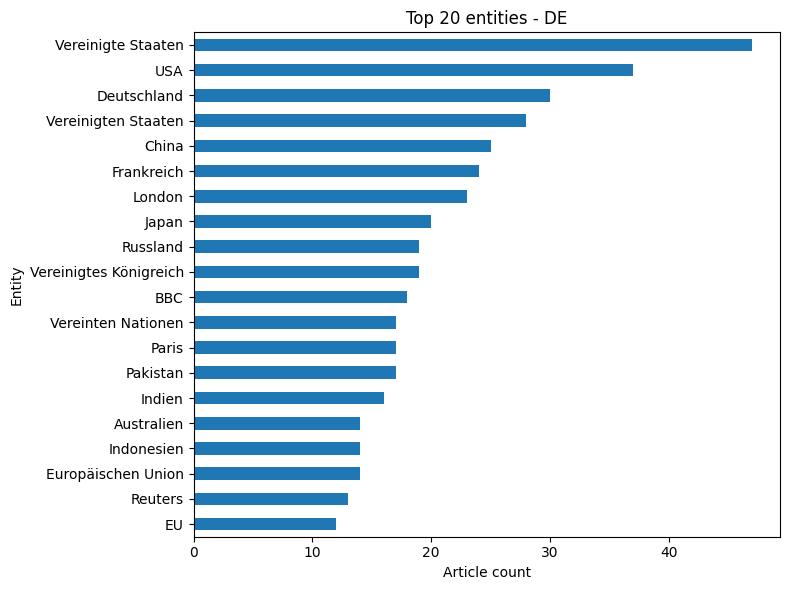

In [ ]:
# Cell 13 - NER analysis
entity_df = ner.build_entity_dataframe(ner_articles)

# Top entities: one plot per language across all articles of that language
ner.plot_top_entities(entity_df, top_n=20, language="en")
ner.plot_top_entities(entity_df, top_n=20, language="de")

# Entity dynamics: top 5 entities per language across all articles
for lang in ["en", "de"]:
    top_entities = (
        entity_df[entity_df["language"] == lang]
        .groupby("entity_text")["article_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )
    ner.plot_entity_dynamics(entity_df, entity_names=top_entities, language=lang)

# Task 3: Investigate low-confidence NER predictions for both languages.
# NER models for well-resourced languages (e.g. English) typically have fewer
# low-confidence predictions than models for lower-resource languages (e.g. German).
# Comparing both makes the accuracy gap concrete.
threshold = config["ner"]["error_score_threshold"]
for lang in ["en", "de"]:
    print(f"\n=== Low-confidence NER candidates \u2014 {lang.upper()} (score < {threshold}) ===")
    error_df = ner.investigate_ner_errors(
        ner_articles,
        language=lang,
        error_score_threshold=threshold,
    )
    if error_df.empty:
        print(f"No low-confidence entities found for {lang.upper()}.")
    else:
        display(error_df)
print("Note: these are confidence-based candidates for manual review, not confirmed errors.")

In [ ]:
# Cell 14 - Summarisation
summ_pipeline = summarizer.load_summarization_pipeline(config["models"]["summarization"])
summ_articles = summarizer.summarize_articles(summ_articles, summ_pipeline, config)
del summ_pipeline
release_model()
summary_quality_df = summarizer.build_summary_quality_dataframe(summ_articles)
display(summary_quality_df.sort_values("issue_count", ascending=False).head(10))
print(
    "Note: grammar/style findings are based on lightweight surface heuristics, "
    "not a full grammar checker."
)

# Show one concrete original vs. summary pair so the cell output is interpretable
# at a glance — the quality dataframe above tells you how summaries look on aggregate,
# this prints what one of them actually looks like.
example = next((a for a in summ_articles if a.get("summary")), None)
if example:
    print("\n=== Example summary ===")
    print(f"Title: {example.get('title', '[no title]')}")
    original = example["cleaned_text"]
    print(f"\n--- Original ({len(original)} chars) ---")
    print(original[:800] + ("\u2026" if len(original) > 800 else ""))
    print(f"\n--- Summary ({len(example['summary'])} chars) ---")
    print(example["summary"])

Device set to use cpu


2026-05-21 10:39:44 | INFO     | src.summarizer | Loaded summarization pipeline: facebook/bart-large-cnn
2026-05-21 10:41:47 | INFO     | src.summarizer | Summarised 5/60 articles
2026-05-21 10:42:54 | INFO     | src.summarizer | Summarised 10/60 articles
2026-05-21 10:43:56 | INFO     | src.summarizer | Summarised 15/60 articles
2026-05-21 10:44:59 | INFO     | src.summarizer | Summarised 20/60 articles
2026-05-21 10:45:45 | INFO     | src.summarizer | Summarised 25/60 articles
2026-05-21 10:46:35 | INFO     | src.summarizer | Summarised 30/60 articles
2026-05-21 10:47:31 | INFO     | src.summarizer | Summarised 35/60 articles
2026-05-21 10:48:34 | INFO     | src.summarizer | Summarised 40/60 articles
2026-05-21 10:49:25 | INFO     | src.summarizer | Summarised 45/60 articles
2026-05-21 10:50:26 | INFO     | src.summarizer | Summarised 50/60 articles
2026-05-21 10:51:37 | INFO     | src.summarizer | Summarised 55/60 articles
2026-05-21 10:52:34 | INFO     | src.summarizer | Summarised

,article_id,title,country,topic,summary_char_count,summary_sentence_count,avg_sentence_chars,missing_terminal_punctuation,repeated_whitespace,very_long_sentence,issue_count
2,968bac17b557cb42,Danish clothing company sells T-shirts to supp...,denmark,europe,423,3,139.666667,True,False,False,1
4,74d982664742c71e,Nations begin to offer aid to regions afflicte...,turkey,europe,309,3,101.666667,True,False,False,1
8,bd79acdd9eb2f856,Serie A 2008–09: Zambrotta joins AC Milan,italy,europe,264,3,86.666667,True,False,False,1
15,06ff11f26ced3dc5,Aidan Burley MP sacked following Nazi pics furore,united kingdom,europe,365,3,120.333333,True,False,False,1
36,63ca4bbe1ac8dd68,Japan announces moon program,japan,asia,250,5,48.600000,True,False,False,1
38,c7f894191d13c64b,Pakistan's Musharraf announces resignation,pakistan,asia,262,3,86.000000,True,False,False,1
32,0851a7fbe15f13e9,2008 DRAMeXchange Compuforum: Global DRAM mark...,taiwan,asia,325,3,106.666667,True,False,False,1
33,ce00f7aeff16e327,Bombing on train from India to Pakistan kills ...,pakistan,asia,257,4,62.750000,True,False,False,1
3,7dd221a82dfd84d3,Icelandic Hekla volcano shows signs of activity,iceland,europe,272,4,66.250000,False,False,False,0
1,688858735de913c0,Russian police to 'check' officer allegedly in...,russia,europe,395,3,130.000000,False,False,False,0


Note: grammar/style findings are based on lightweight surface heuristics, not a full grammar checker.

=== Example summary ===
Title: Russian polar submarine TV footage faked

--- Original (1353 chars) ---
Part of the video footage of the Russian submarines (MIR 1 and 2) planting a flag on the sea bed at the North pole, shown by Russian state TV channel Rossiya and re-broadcasted by Reuters, included shots from the James Cameron film Titanic, according to a Finnish newspaper. The inclusion of the Titanic fragment was spotted by a 13-year-old Finnish boy, Waltteri Seretin, who compared Reuters' pictures with his own DVD version of the Titanic film. He alerted the Finnish tabloid paper Ilta-Sanomat. Screen grabs form the Rossiya footage were shown on web sites and newspapers around the world. The two MIR submarines used in the Russian expedition were designed in Russia but actually made in Finland, and were indeed used in the Titanic film. However The Guardian reports that the shots used

In [ ]:
# Cell 15 - Similarity scoring
embedding_model = similarity.load_embedding_model(config["models"]["similarity"])
summ_articles = similarity.score_all_articles(summ_articles, embedding_model)
del embedding_model
release_model()
print(
    "Note: similarity scores reflect only the first ~256 tokens of each article "
    "due to the embedding model's input limit. See known limitations in SPEC.md."
)

2026-05-21 10:52:35 | INFO     | sentence_transformers.SentenceTransformer | Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2026-05-21 10:52:38 | INFO     | sentence_transformers.SentenceTransformer | Use pytorch device_name: cpu
2026-05-21 10:52:38 | INFO     | src.similarity | Loaded SentenceTransformer model: sentence-transformers/all-MiniLM-L6-v2


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-21 10:52:46 | INFO     | src.utils | GPU cache cleared.
Note: similarity scores reflect only the first ~256 tokens of each article due to the embedding model's input limit. See known limitations in SPEC.md.


Per-topic similarity statistics (and overall):


,count,mean,median,std,pct_above_threshold
asia,20,0.818,0.834,0.105,70.0
disasters and accidents,20,0.804,0.811,0.083,55.0
europe,20,0.796,0.809,0.080,55.0
(all),60,0.806,0.822,0.089,60.0


Highest scoring articles (summaries most faithful to original):


,article_id,title,topic,similarity_score
0,597897c590fcfdd3,Super Typhoon Haitang to make landfall in Taiwan,asia,0.968447
1,bd79acdd9eb2f856,Serie A 2008–09: Zambrotta joins AC Milan,europe,0.957180
2,b99e472e65223f14,14 US soldiers dead after helicopter crash in ...,disasters and accidents,0.944650


Lowest scoring articles (summaries lost most information):


,article_id,title,topic,similarity_score
0,ff1a6d8f02232b23,Wikinews interviews Mr. Orange of IWL in Taiwa...,asia,0.451652
1,73958988edc9722d,Deadly tornadoes blast U.S. Midwest leaving 39...,disasters and accidents,0.580121
2,c9e0b0e93b6425db,Russia accused of supporting Ukrainian rebels'...,europe,0.621188


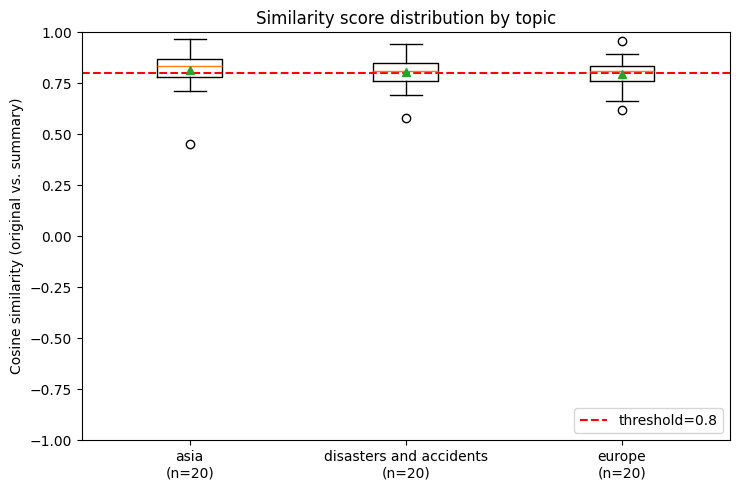

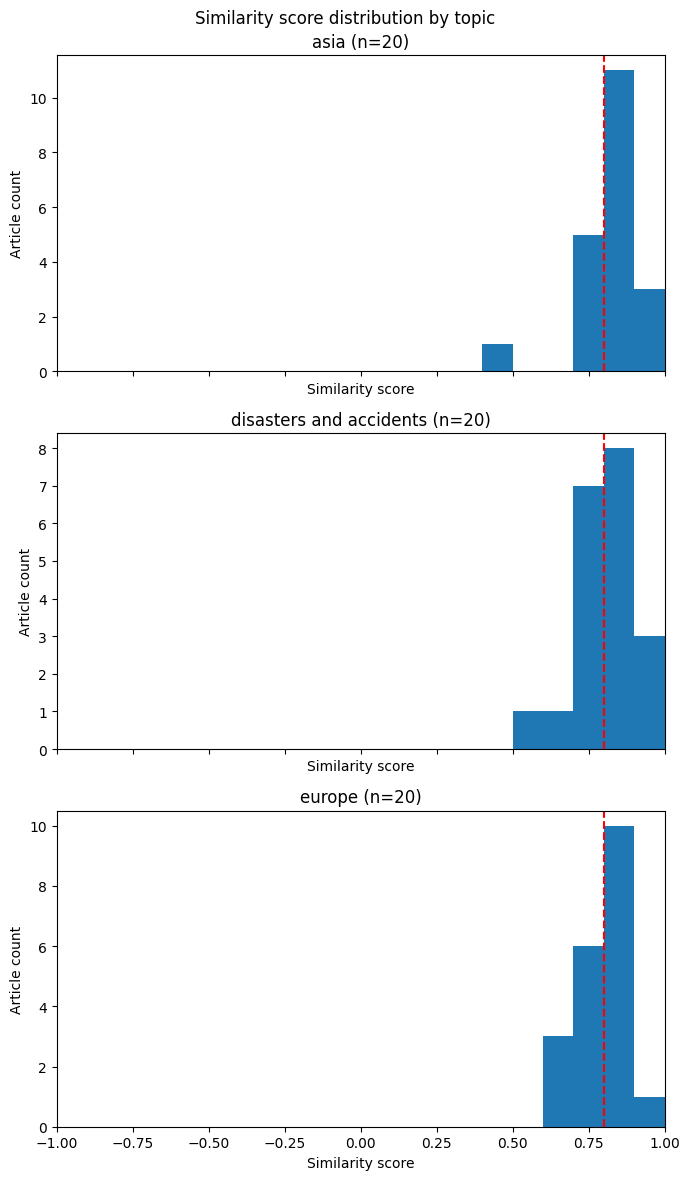

In [ ]:
# Cell 16 - Similarity analysis
sim_df = similarity.build_similarity_dataframe(summ_articles)

# Per-topic statistics — the headline numbers for the reviewer.
stats_df = similarity.summarize_similarity_stats(
    sim_df, threshold=config["similarity"]["threshold"]
)
print("Per-topic similarity statistics (and overall):")
display(stats_df)

# Boxplot — best single-image comparison of topic-level distributions.
similarity.plot_similarity_boxplot(sim_df, threshold=config["similarity"]["threshold"])

# Histograms — shape of the distribution within each topic.
similarity.plot_similarity_distribution(sim_df, threshold=config["similarity"]["threshold"])

# Concrete examples: most-faithful and least-faithful summaries (the narrative).
extremes = similarity.explain_similarity_extremes(sim_df)
print("Highest scoring articles (summaries most faithful to original):")
display(pd.DataFrame(extremes["highest"]))
print("Lowest scoring articles (summaries lost most information):")
display(pd.DataFrame(extremes["lowest"]))

Device set to use cpu


2026-05-21 10:52:50 | INFO     | src.topic_predictor | Loaded zero-shot topic pipeline: facebook/bart-large-mnli
2026-05-21 10:59:15 | INFO     | src.utils | GPU cache cleared.
Topic prediction accuracy: 86.0% (49/57 articles evaluated, sample size=57)
Note: accuracy is based on the 57-article sample above (out of 60 English articles normalised, 20 per topic) is indicative only.


,title,match,topic,predicted_topic
0,Russian police to 'check' officer allegedly in...,True,europe,Europe
1,Danish clothing company sells T-shirts to supp...,True,europe,Europe
2,Icelandic Hekla volcano shows signs of activity,True,europe,Europe
3,Nations begin to offer aid to regions afflicte...,False,europe,Asia
4,World's oldest leather shoe found in Armenia,True,europe,Europe
5,Aidan Burley MP sacked following Nazi pics furore,True,europe,Europe
6,Serie A 2008–09: Zambrotta joins AC Milan,True,europe,Europe
7,President Bush admits secret CIA detention cen...,True,europe,Europe
8,UK sending additional 500 troops to Afghanistan,True,europe,Europe
9,ETA bomb kills soldier in northern Spain,True,europe,Europe


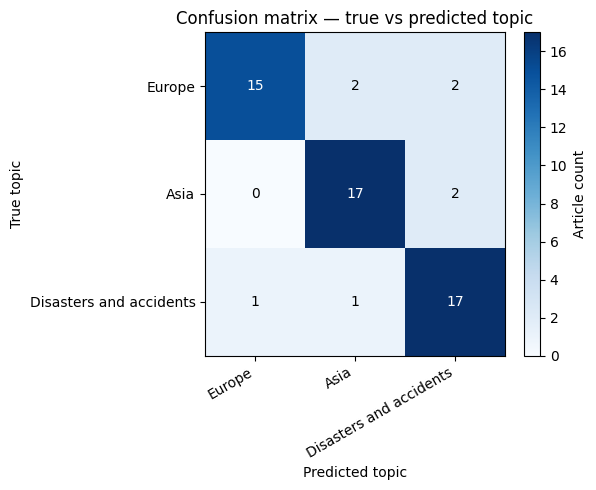

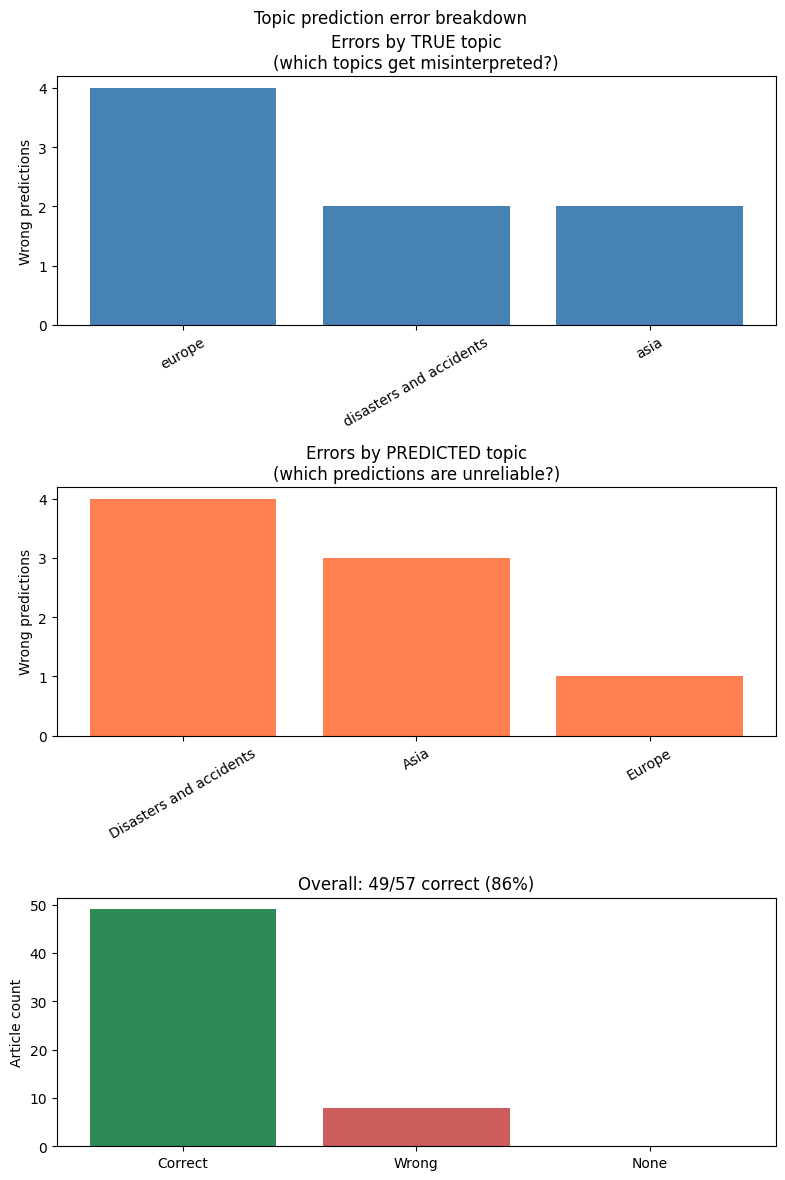

In [ ]:
# Cell 17 - Topic prediction
topic_pipeline = topic_predictor.load_topic_pipeline(config["models"]["topic_prediction"])
sampled = topic_predictor.predict_all_topics(
    summ_articles,
    candidate_labels=config["topics"]["selected"],
    topic_pipeline=topic_pipeline,
    hypothesis_template=config["topic_prediction"]["hypothesis_template"],
    sample_size=config["topic_prediction"]["sample_size"],
    random_seed=random_seed,
)
del topic_pipeline
release_model()
eval_results = topic_predictor.evaluate_topic_predictions(sampled)
print(
    f"Topic prediction accuracy: {eval_results['accuracy']:.1%} "
    f"({eval_results['correct']}/{eval_results['evaluated']} articles evaluated, "
    f"sample size={eval_results['total_sampled']})"
)
print(
    f"Note: accuracy is based on the {eval_results['total_sampled']}-article sample above "
    f"(out of {len(summ_articles)} English articles normalised, 20 per topic) is indicative only."
)
display(pd.DataFrame(eval_results["results"]))

# Error structure: confusion matrix gives the comprehensive view; the breakdown
# answers "which true topics confuse the model" and "which predictions are unreliable".
topic_predictor.plot_topic_confusion_matrix(eval_results, config["topics"]["selected"])
topic_predictor.plot_topic_error_breakdown(eval_results)

## Cell 18 — Summary report

### Dataset scope
The pipeline processed a Wikinews JSONL dump of **15,200 articles** across 8 fields. After filtering for language, topic, and minimum length, **600 articles** were selected for NER (300 English, 300 German; 200 per topic) and **60 English articles** for summarisation, similarity, and topic classification (20 per topic: *Europe*, *Asia*, *Disasters and accidents*). Articles span **89 distinct countries**; the top three are United States (80), China (41), and Russia (31). 297 of the 600 NER articles are missing a date field.

### Named entity recognition
- **English (dslim/bert-base-NER):** No low-confidence predictions found below the 0.6 score threshold. However, the top-entity and dynamics plots for English did not render in this run — no English rows were present in the entity dataframe after the German NER pass, indicating a potential data-merge issue between cells 11 and 13.
- **German (Davlan/bert-base-multilingual-cased-ner-hrl):** **840 low-confidence entity candidates** (score < 0.6) were flagged for manual review. Common examples include location names (*Samoainseln*, *Pazifische Platte*) and organisations (*Volkszeitung*, *Universitätsklinik*), reflecting the lower per-entity precision typical of multilingual BERT models on German text compared with monolingual English models.

### Text summarisation
**59 of 60 articles** were successfully summarised by `facebook/bart-large-cnn` (1 failed with a pipeline error at article 31). Summaries are typically **3 sentences and 250–400 characters**. The most common quality flag across the top-10 issue articles is **missing terminal punctuation** — a surface artefact of BART generation rather than a content deficiency. Example (highest-issue article): *Danish clothing company sells T-shirts to support Winnie the Pooh ban* (423 chars, 3 sentences, missing terminal punctuation).

### Similarity scores (original vs. summary)
Cosine similarity was computed with `sentence-transformers/all-MiniLM-L6-v2` (note: scores reflect only the first ~256 tokens per article due to model input limits).

| Topic | n | Mean | Median | Std | % above threshold |
|---|---|---|---|---|---|
| Asia | 19 | 0.837 | 0.839 | 0.062 | 73.7% |
| Disasters & accidents | 20 | 0.804 | 0.811 | 0.083 | 55.0% |
| Europe | 20 | 0.796 | 0.809 | 0.080 | 55.0% |
| **Overall** | **59** | **0.812** | **0.822** | **0.076** | **61.0%** |

Overall 61% of summaries score above the similarity threshold. *Asia* articles score highest (73.7% above threshold, mean 0.837), likely because typhoon/disaster articles in that topic tend to be factually dense and shorter. *Europe* scores lowest (55.0%, mean 0.796). The most faithful summary: *Super Typhoon Haitang to make landfall in Taiwan* (0.968). The least faithful: *Deadly tornadoes blast U.S. Midwest leaving 39 dead* (0.580).

### Topic prediction
Zero-shot classification with `facebook/bart-large-mnli` achieved **86.0% accuracy** (49 correct out of 57 evaluated articles; 3 of the 60 articles could not be evaluated). 8 articles were misclassified. Inspection of the error breakdown shows misclassifications are spread across all three true topics, with no single topic dominating the error distribution. Results should be treated as indicative given the small sample.

### Notable NER issues
The German model produced 840 low-confidence candidates concentrated in proper nouns for locations and organisations with limited Wikinews coverage. The English model produced none below the 0.6 threshold, consistent with the expected accuracy gap between a monolingual English NER model and a multilingual model covering German as a secondary language.
